### Question 1 (20 points)

Let us explore how to perform an RFM analysis by dividing customers into quintiles. For each customer,
you'll look at Recency, the maximum number of days since 2024-12-31, along with the median number
of items purchased (Frequency), and the total transaction amounts (Monetary). Even if some
transactions show zero or negative item counts or quantities, don't worry — you'll include all of them in
your analysis to get a complete picture.

In [ ]:
import matplotlib.pyplot as plt
import numpy
import pandas
from datetime import datetime

In [61]:
# load dataset
import pandas as pd
df = pd.read_excel("Grocery_Runs.xlsx")

In [62]:
df.head()

,Customer_ID,Transaction_Date,Number_Items,Transaction_Amount
0,A00000,2025-02-01,12,49.17
1,A00000,2025-02-15,18,73.63
2,A00000,2025-02-23,18,69.28
3,A00000,2025-03-15,16,60.24
4,A00000,2025-03-15,13,47.74


In [63]:
df.dtypes

Customer_ID                   object
Transaction_Date      datetime64[ns]
Number_Items                   int64
Transaction_Amount           float64
dtype: object

(a) (10 points) What are the quintiles for Recency, Frequency, and Monetary values?

code for this question was taken from Dr. Lam from Week 4 RFM Analysis.py

In [64]:
# create column for days since 2024-12-31
t_date = pandas.to_datetime(df['Transaction_Date'])
reference_date = datetime.strptime('2024-12-31', "%Y-%m-%d")
n_days = pandas.Series((t_date - reference_date) / numpy.timedelta64(1, 'D'), name
= 'Recency')

In [65]:
# Create the training data
train_data = df[['Customer_ID', 'Transaction_Date', 'Transaction_Amount']].join(n_days)
train_data.head()

,Customer_ID,Transaction_Date,Transaction_Amount,Recency
0,A00000,2025-02-01,49.17,32.0
1,A00000,2025-02-15,73.63,46.0
2,A00000,2025-02-23,69.28,54.0
3,A00000,2025-03-15,60.24,74.0
4,A00000,2025-03-15,47.74,74.0


In [66]:
# Define the aggregation procedure outside of the groupby operation
aggregations = {
'Recency':'max',
'Customer_ID': 'count',
'Transaction_Amount': 'sum'
}

column_map = {'Recency': 'Recency', 'Customer_ID': 'Frequency', 'Transaction_Amount': 'Monetary'}
customer_data = train_data.groupby('Customer_ID').agg(aggregations).rename(columns =
column_map)
rfm_names = customer_data.columns

# Determine the quintiles
quintile = customer_data[rfm_names].quantile([0.2, 0.4, 0.6, 0.8])
quintile

,Recency,Frequency,Monetary
0.2,336.0,13.0,381.362
0.4,354.0,29.0,1589.064
0.6,361.0,39.0,2276.364
0.8,365.0,50.0,2867.122


(b) (10 points) Generate a separate vertical bar chart for each Recency, Frequency, and Monetary
group. Display the three bar charts in the same chart frame.

In [70]:
# Assign the customer groups
customer_group = pandas.DataFrame(numpy.where(numpy.isnan(customer_data),0, 1), index = customer_data.index, columns = customer_data.columns)
for q in [0.2, 0.4, 0.6, 0.8]:
    customer_group = customer_group + numpy.where(customer_data[rfm_names] > quintile.loc[q][rfm_names],1,0)
customer_group = customer_group.rename(columns = {'Recency': 'Recency Group', 'Frequency': 'Frequency Group', 'Monetary': 'Monetary Group'})
customer_group.head()

,Recency Group,Frequency Group,Monetary Group
Customer_ID,,,
A00000,4,3,3
A00001,3,2,3
A00002,3,1,2
A00003,1,4,4
A00004,1,1,1


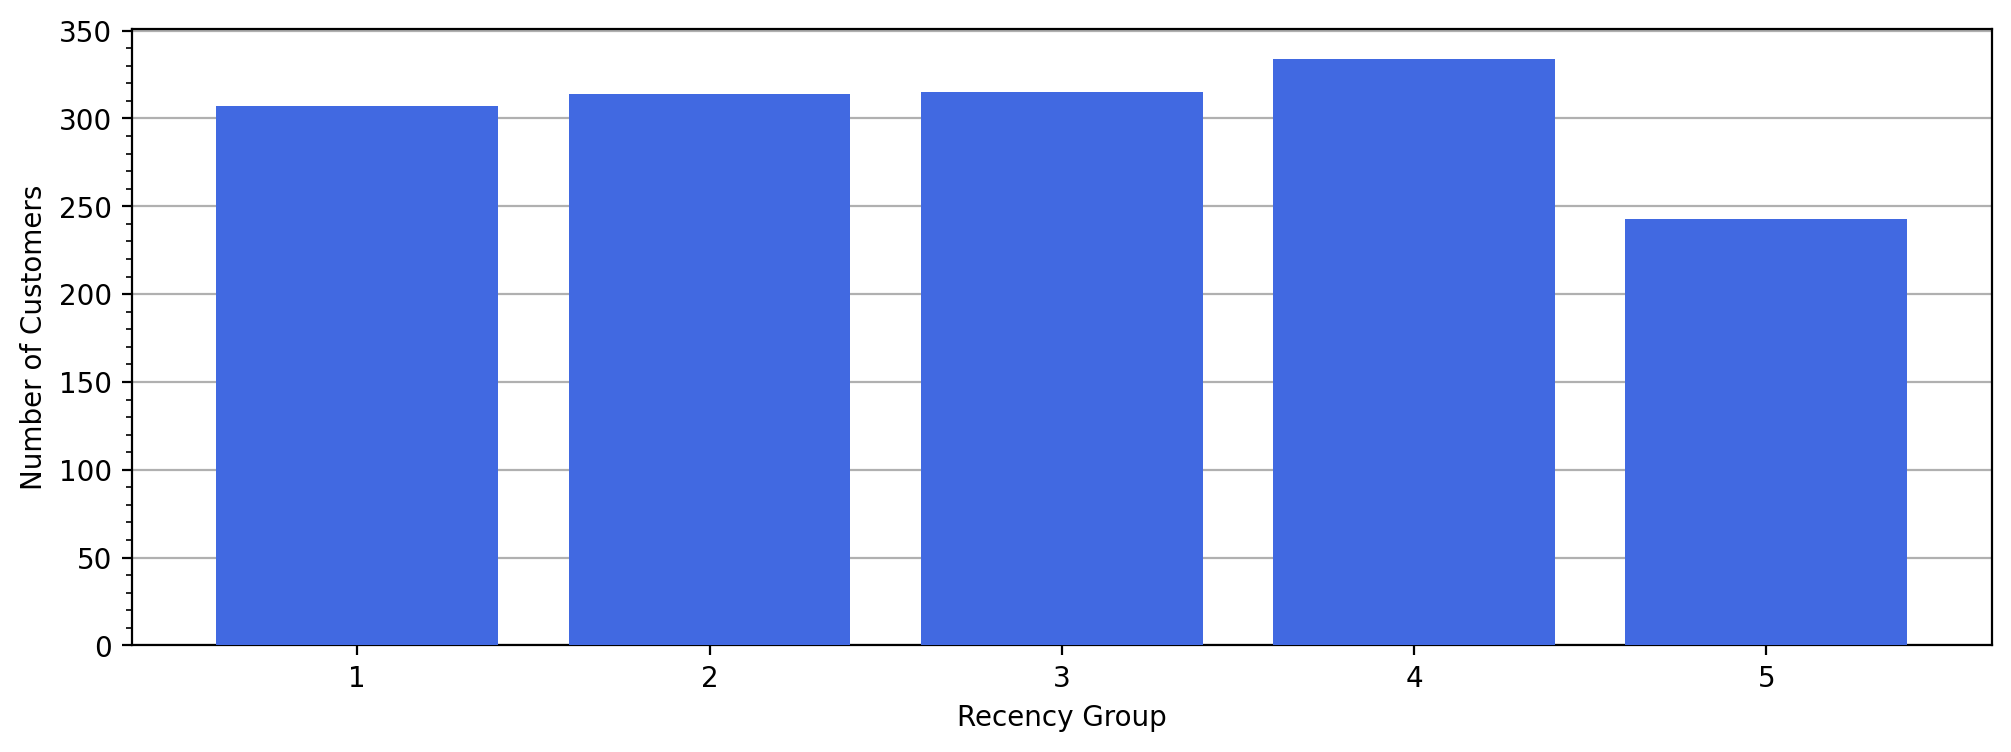

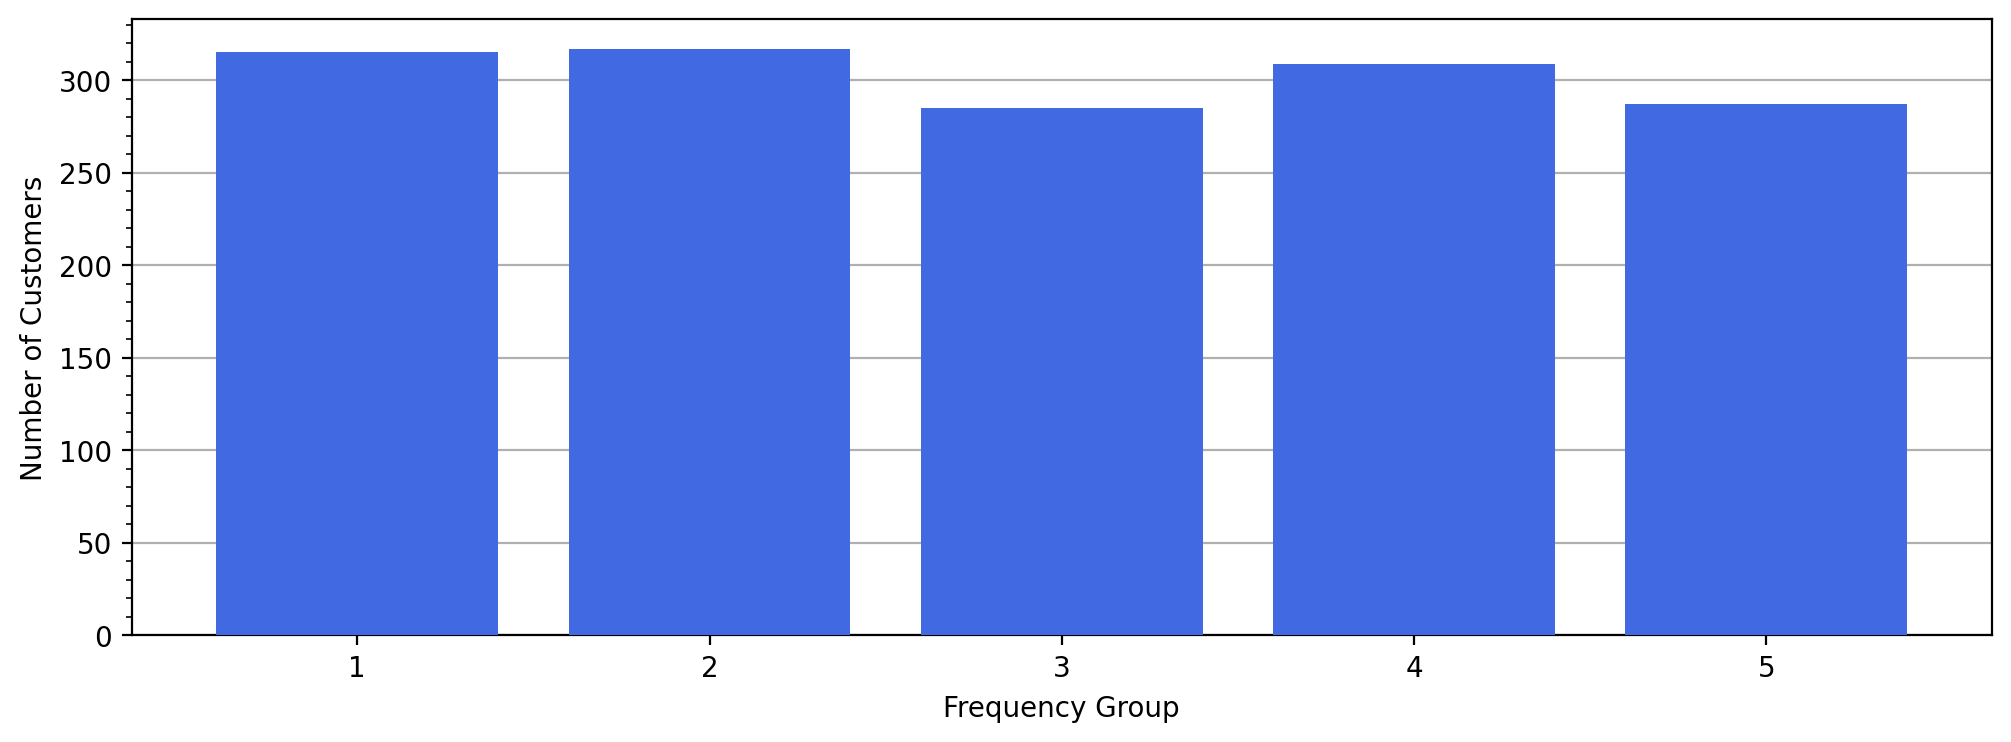

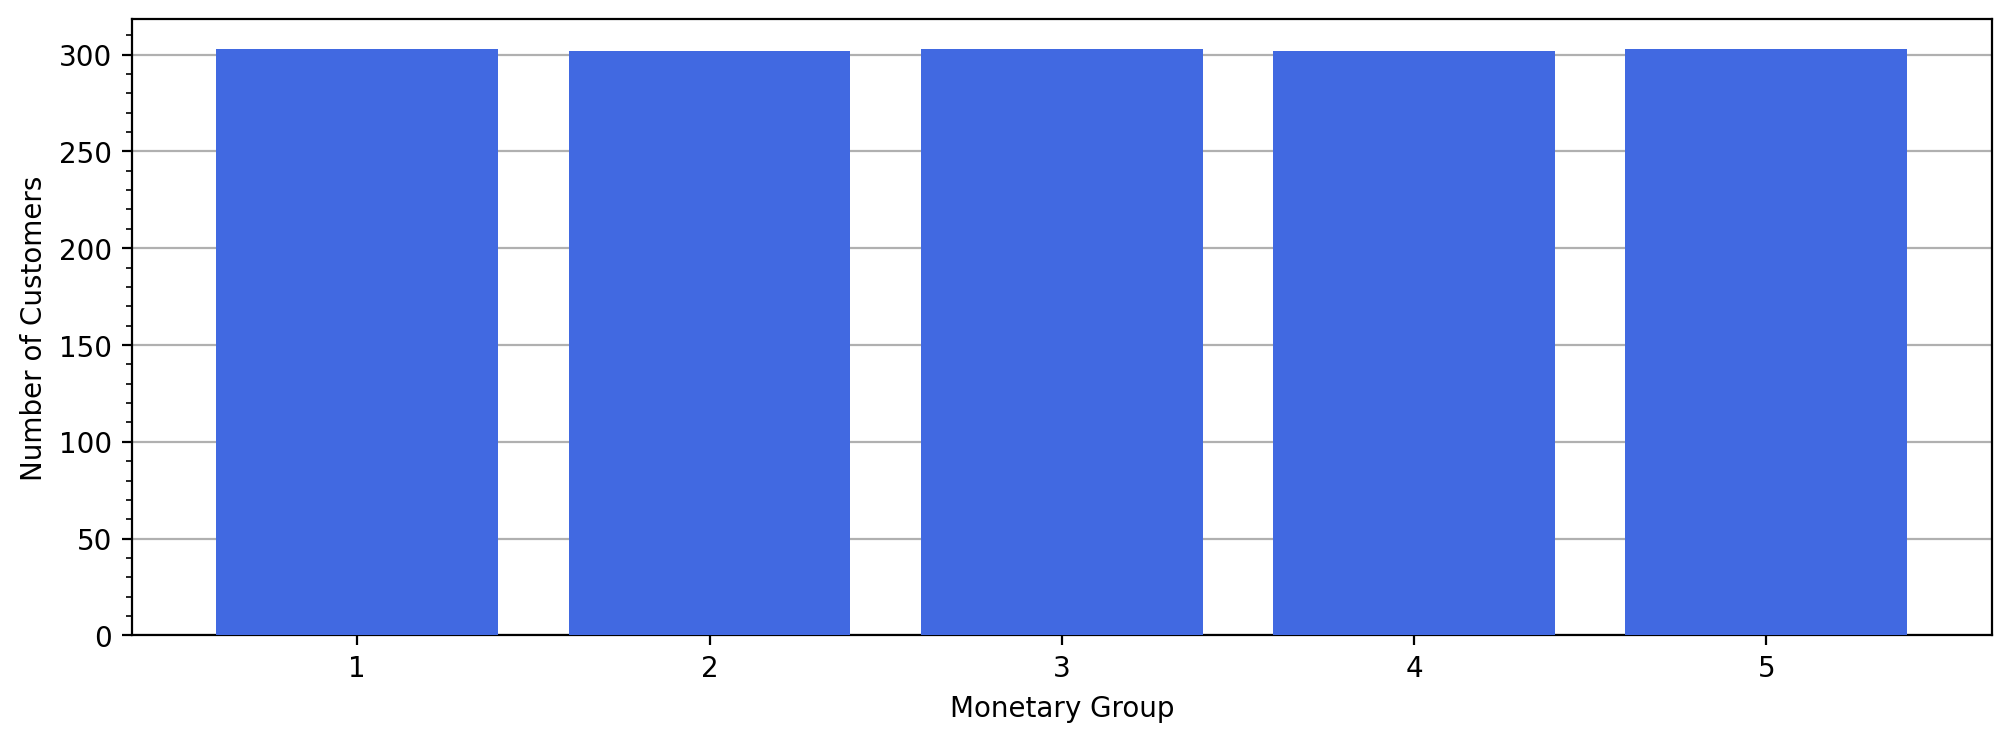

In [71]:
# Inspect bar charts of each group
from matplotlib.ticker import MultipleLocator

for g in ['Recency Group', 'Frequency Group','Monetary Group']:
    group_size = customer_group[g].value_counts(ascending = True)
    fig, ax = plt.subplots(figsize = (12,4), dpi = 200)
    ax.bar(group_size.index, group_size, color = 'royalblue', zorder = 3)
    ax.set_xlabel(g)
    ax.set_ylabel('Number of Customers')
    ax.set_xticks(range(1,6,1))
    ax.yaxis.set_major_locator(MultipleLocator(base = 50))
    ax.yaxis.set_minor_locator(MultipleLocator(base = 10))
    ax.yaxis.grid(True, linestyle = '-', zorder = 0)
    plt.show()

### Question 2 (20 points)

Once you've rescaled the Recency, Frequency, and Monetary values to a range of 0 to 100, you'll perform k-means clustering on these rescaled numbers. 


In [ ]:
# NOT NEEDED
# Merge the group assignments back to the customer data
train_data = customer_data.join(customer_group)
customer_data['RFM Score'] = 100 * customer_data['Recency Group'] + 10 * customer_data['Frequency Group'] + customer_data['Monetary Group']

# Copy the RFM Score back to the transaction data
transaction_rfm = df.merge(customer_data['RFM Score'], left_on =
['Customer_ID'], right_on=customer_data.index)

transaction_rfm.head()

,Customer_ID,Transaction_Date,Number_Items,Transaction_Amount,RFM Score
0,A00000,2025-02-01,12,49.17,433
1,A00000,2025-02-15,18,73.63,433
2,A00000,2025-02-23,18,69.28,433
3,A00000,2025-03-15,16,60.24,433
4,A00000,2025-03-15,13,47.74,433


In [ ]:
customer_data.head()

,Recency,Frequency,Monetary,Recency Group,Frequency Group,Monetary Group,RFM Score,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
Customer_ID,,,,,,,,,,
A00000,365.0,30,1791.59,4,3,3,433,99.449036,31.868132,34.315205
A00001,357.0,25,1698.17,3,2,3,323,97.245179,26.373626,32.525886
A00002,359.0,9,1268.18,3,1,2,312,97.796143,8.791209,24.290076
A00003,330.0,43,2571.80,1,4,4,144,89.807163,46.153846,49.258951
A00004,42.0,5,159.53,1,1,1,111,10.468320,4.395604,3.055557


In [ ]:

# 1. Isolate the raw RFM columns
# We assume 'Customer_ID' is the index based on your previous display
traindata = customer_data[['Recency', 'Frequency', 'Monetary']].copy()

# 2. Rescale to 0-100 range
# Formula: ((x - min) / (max - min)) * 100
traindata = (traindata - traindata.min()) / (traindata.max() - traindata.min()) * 100

# 3. Reset the index to ensure join alignment inside KMeansCluster
traindata = traindata.reset_index(drop=True)

Scaled Data Head:


Recency      100.0
Frequency    100.0
Monetary     100.0
dtype: float64

(a)	(10 points) Try the number of clusters between 2 and 15, inclusive, then plot the Elbow values, the Silhouette Scores, the Calinski and Harabasz Scores, and the Davies-Bouldin Scores versus the number of clusters. Your initial random seed is 710136264; add 31 after each trial.

In [ ]:
## This code is taken from Dr. Lam from in class example file "Week 4 KMeans 2D Example.py"
import random
from sklearn import metrics
def getPositionSRS (nObs, nCluster):
    '''Get positions of centroids for the clusters by simple random sampling method
    Arguments:
    1. trainData - training data
    2. nObs - number of observations in training data (assume nObs > nCluster)
    3. nCluster - number of clusters
    Output:
    1. centroid_pos - positions in training data chosen as centroids
    '''
    centroid_pos = []
    kObs = 0
    iSample = 0
    for iObs in range(nObs):
        kObs = kObs + 1
        uThreshold = (nCluster - iSample) / (nObs - kObs + 1)
        if (random.random() < uThreshold):
            centroid_pos.append(iObs)
            iSample = iSample + 1
        if (iSample == nCluster):
            break
    return (centroid_pos)


def assignMember (trainData, centroid, distType):
    '''Assign observations to their nearest clusters.
    Arguments:
    1. trainData - training data
    2. centroid - centroid
    3. distType - distance metric
    Output:
    1. member - cluster memberships
    2. wc_distance - distances of observations to the nearest centroid
    '''
    pair_distance = metrics.pairwise_distances(trainData, centroid, metric =
    distType)
    member = pandas.Series(numpy.argmin(pair_distance, axis = 1), name = 'Cluster')
    wc_distance = pandas.Series(numpy.min(pair_distance, axis = 1), name =
    'Distance')
    return (member, wc_distance)

def KMeansCluster (trainData, nCluster, distType = 'euclidean', nIteration = 500, nTrial = 10, randomSeed = None):
    n_obs = trainData.shape[0]
    if (randomSeed is not None):
        random.seed(a = randomSeed)

    list_centroid = []
    list_wcss = []

    for iTrial in range(nTrial):
        centroid_pos = getPositionSRS(n_obs, nCluster)
        centroid = trainData.iloc[centroid_pos]
        member_prev = pandas.Series([-1] * n_obs, name = 'Cluster')

        for iter in range(nIteration):
            member, wc_distance = assignMember(trainData, centroid, distType)
            centroid = trainData.join(member).groupby(by = ['Cluster']).mean()
            member_diff = numpy.sum(numpy.abs(member - member_prev))
            if (member_diff > 0):
                member_prev = member
            else:
                break
        print(centroid)

        list_centroid.append(centroid)
        list_wcss.append(numpy.sum(numpy.power(wc_distance,2)))

    best_solution = numpy.argmin(list_wcss)
    centroid = list_centroid[best_solution]
    member, wc_distance = assignMember(trainData, centroid, distType)
    return (member, centroid, wc_distance)

In [ ]:
# 1. Initialize storage for metrics
nClusters = []
Elbow = []
Silhouette = []
CH_score = []
DB_score = []
TotalWCSS = []

max_nCluster = 15

for k_idx in range(max_nCluster):
    nCluster = k_idx + 1
    
    # Generate seed
    current_seed = 710136264 + (31 * k_idx)
    
    # Run KMeans function
    member, centroid, wc_distance = KMeansCluster(
        traindata, 
        nCluster, 
        distType='euclidean', 
        nTrial=20, 
        randomSeed=current_seed
    )
    
    # Calculate Total WCSS and Elbow (Mean WCSS)
    T = numpy.sum(numpy.power(wc_distance, 2))
    E = numpy.mean(numpy.power(wc_distance, 2))
    
    # Metrics requiring at least 2 clusters
    if nCluster > 1:
        S = metrics.silhouette_score(traindata, member, metric='euclidean')
        CH = metrics.calinski_harabasz_score(traindata, member)
        DB = metrics.davies_bouldin_score(traindata, member)
    else:
        # Defaults for k=1
        S, CH, DB = numpy.nan, numpy.nan, numpy.nan
        
    # Append results ONCE per k value
    nClusters.append(nCluster)
    TotalWCSS.append(T)
    Elbow.append(E)
    Silhouette.append(S)
    CH_score.append(CH)
    DB_score.append(DB)

# Create the Summary DataFrame
result_df = pandas.DataFrame({
    'N Cluster': nClusters,
    'Total WCSS': TotalWCSS,
    'Elbow': Elbow,
    'Silhouette': Silhouette,
    'CH Score': CH_score,
    'DB Score': DB_score
})

           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recency  Frequency   Monetary
Cluster                                 
0        89.250372  35.258529  34.984702
           Recen

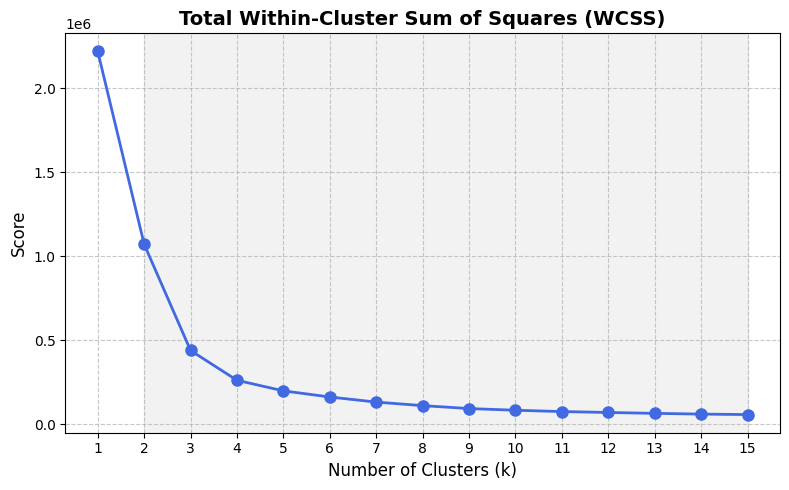

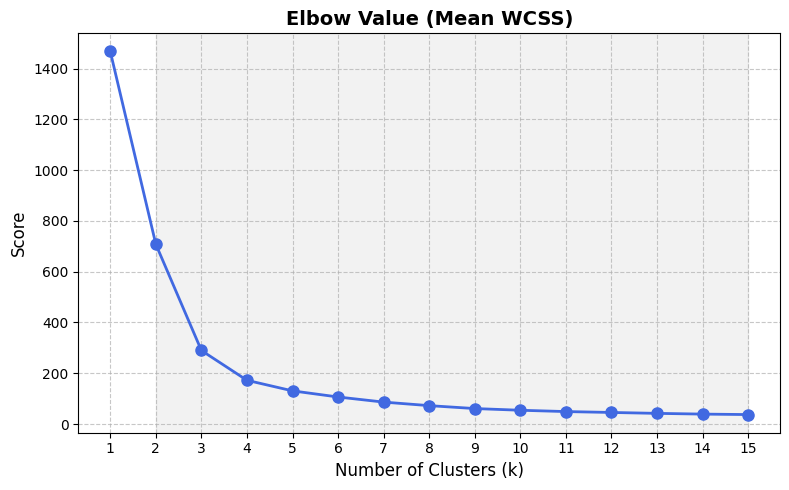

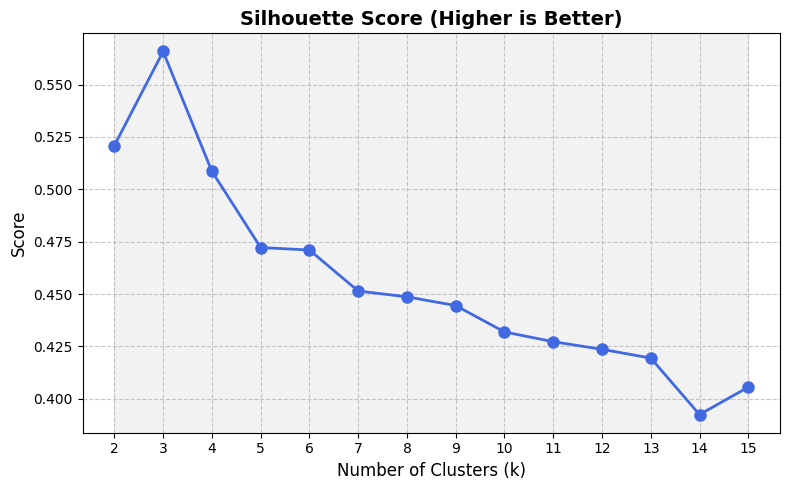

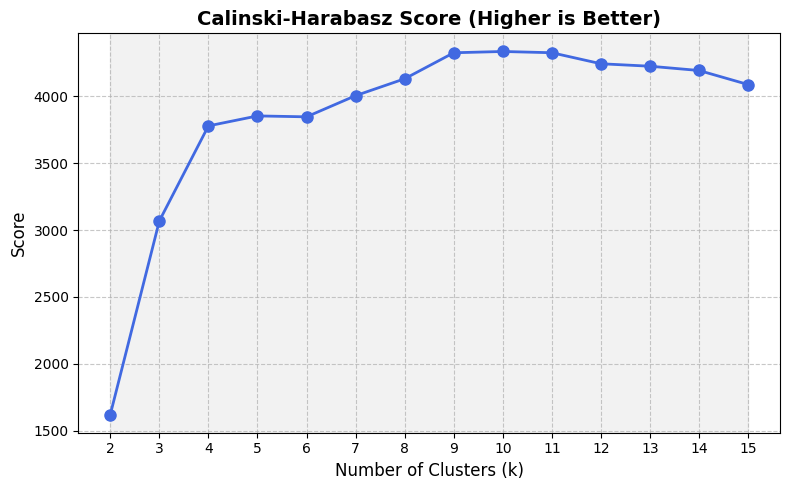

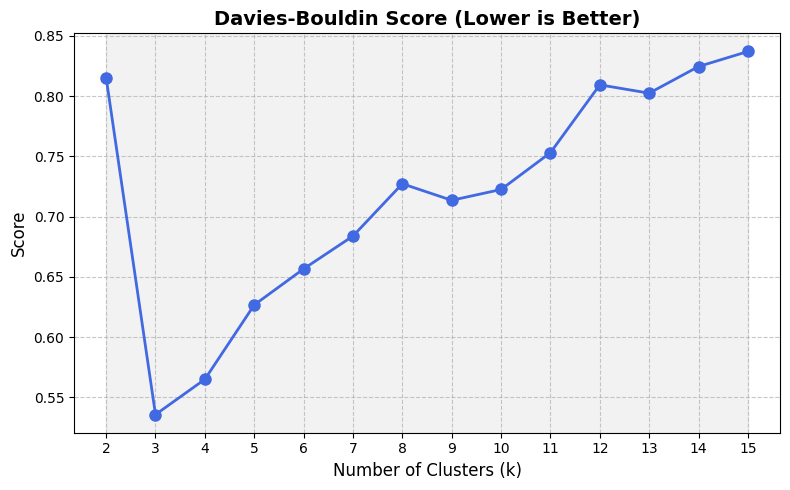

In [ ]:
import matplotlib.pyplot as plt

# Ensure we are only plotting for nCluster >= 2 for the evaluation scores
# (Silhouette, CH, and DB are not defined for k=1)
plot_df = result_df[result_df['N Cluster'] >= 2]

metrics_to_plot = [
    ('Total WCSS', 'Total Within-Cluster Sum of Squares (WCSS)'),
    ('Elbow', 'Elbow Value (Mean WCSS)'),
    ('Silhouette', 'Silhouette Score (Higher is Better)'),
    ('CH Score', 'Calinski-Harabasz Score (Higher is Better)'),
    ('DB Score', 'Davies-Bouldin Score (Lower is Better)')
]

for column, title in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    
    # Use the full range for WCSS/Elbow, but 2-15 for the others
    data_to_use = result_df if 'WCSS' in column or 'Elbow' in column else plot_df
    
    plt.plot(data_to_use['N Cluster'], data_to_use[column], 
             marker='o', linestyle='-', color='royalblue', linewidth=2, markersize=8)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.xticks(range(1, 16))
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Highlight the 2-15 range
    plt.axvspan(2, 15, color='gray', alpha=0.1, label='Target Range (2-15)')
    
    plt.tight_layout()
    plt.show()

(b)	(10 points) What will you suggest for the number of clusters based on the four metrics?

### Question 3 (20 points)

Use the t-Distributed Stochastic Neighbor Embedding (t-SNE) method to project the scaled Recency, Frequency, and Monetary values into a two-dimensional space.  You will try perplexity values between 5 and 50 in increments of 5.  Your initial random seed is 710136202; add 31 after each trial.



In [76]:
# import umap
from matplotlib.ticker import AutoLocator, MultipleLocator, PercentFormatter
from pandas.plotting import scatter_matrix
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score, silhouette_score)
import numpy as np

In [87]:
# This is code taken from Dr. Lam in the file "Week 4 Visualize High Dimensional Data.py"

# Calculate the elbow value for a given cluster solution
def elbow_value (X, cluster_member, cluster_centroid):
    n_cluster = cluster_centroid.shape[0]
    WCSS = [0.0] * n_cluster
    cluster_count = [0.0] * n_cluster
    irow = 0
    for index, row in X.iterrows():
        k = cluster_member[irow]
        diff = row - cluster_centroid[k]
        WCSS[k] += diff.dot(diff)
        cluster_count[k] += 1.0
        irow += 1
        elbow = 0.0
    for k in range(n_cluster):
        if (cluster_count[k] > 0.0):
            elbow += WCSS[k] / cluster_count[k]
    return (elbow)

# Suggest the best guess for the number of clusters
def suggest_n_clusters(train_data, test_data=None, k_choices=range(2,11,1), random_seed=710136264):
    aseed = random_seed
    result_list = []
    # Define base metric names first
    metric_name = ['N Clusters', 'Elbow Train', 'Silhouette Train', 'CH Train', 'DB Train']

    for k in k_choices:
        aseed += 31
        # Using KMeans from sklearn
        obj_kmeans = KMeans(n_clusters=k, init='random', n_init='auto', random_state=aseed)
        cluster_train = obj_kmeans.fit(train_data)
        
        # Calculate training metrics
        elbow_train = obj_kmeans.inertia_ # Often used for Elbow value
        silhouette_train = silhouette_score(train_data, cluster_train.labels_)
        ch_train = calinski_harabasz_score(train_data, cluster_train.labels_)
        db_train = davies_bouldin_score(train_data, cluster_train.labels_)
        
        this_result = [k, elbow_train, silhouette_train, ch_train, db_train]
        
        if test_data is not None:
            test_labels = cluster_train.predict(test_data)
            elbow_test = elbow_value(test_data, test_labels, cluster_train.cluster_centers_)
            silhouette_test = silhouette_score(test_data, test_labels)
            ch_test = calinski_harabasz_score(test_data, test_labels)
            db_test = davies_bouldin_score(test_data, test_labels)
            # Append test metrics to the result list
            this_result.extend([elbow_test, silhouette_test, ch_test, db_test])
            
        result_list.append(this_result)

    # If test data was provided, update the column headers
    if test_data is not None:
        metric_name.extend(['Elbow Test', 'Silhouette Test', 'CH Test', 'DB Test'])

    metric_df = pandas.DataFrame(result_list, columns=metric_name)
    return metric_df


# Display graphs of metrics of the training data
def show_cluster_metric (metric_df):
    fig, axs = plt.subplots(2, 2, figsize = (12,8), dpi = 200, sharex = True)
    fig.subplots_adjust(hspace = 0.1, wspace = 0.2)

    ax = axs[0,0]
    ax.plot(metric_df['N Clusters'], metric_df['Elbow Train'], marker = 'o', color = 'royalblue')
    ax.set_xlabel('')
    ax.set_ylabel('Elbow Value')
    ax.set_xticks(metric_df['N Clusters'])
    ax.grid(axis = 'both', linestyle = ':', linewidth = 0.5)

    ax = axs[0,1]
    ax.plot(metric_df['N Clusters'], metric_df['Silhouette Train'], marker = 'o',
    color = 'crimson')
    ax.set_xlabel('')
    ax.set_ylabel('Silhouette Score')
    ax.set_xticks(metric_df['N Clusters'])
    ax.grid(axis = 'both', linestyle = ':', linewidth = 0.5)

    ax = axs[1,0]
    ax.plot(metric_df['N Clusters'], metric_df['CH Train'], marker = 'o', color =
    'seagreen')
    ax.set_xlabel('Number of Clusters')
    ax.set_ylabel('Calinski and Harabasz Score')
    ax.set_xticks(metric_df['N Clusters'])
    ax.grid(axis = 'both', linestyle = ':', linewidth = 0.5)

    ax = axs[1,1]
    ax.plot(metric_df['N Clusters'], metric_df['DB Train'], marker = 'o', color = 'turquoise')
    ax.set_xlabel('Number of Clusters')
    ax.set_ylabel('Davies-Bouldin Score')
    ax.set_xticks(metric_df['N Clusters'])
    ax.grid(axis = 'both', linestyle = ':', linewidth = 0.5)
    plt.show()
    return None


(a)	(10 points) Generate a scatterplot of the embeddings for each perplexity value. Display the ten scatterplots in the same chart frame.

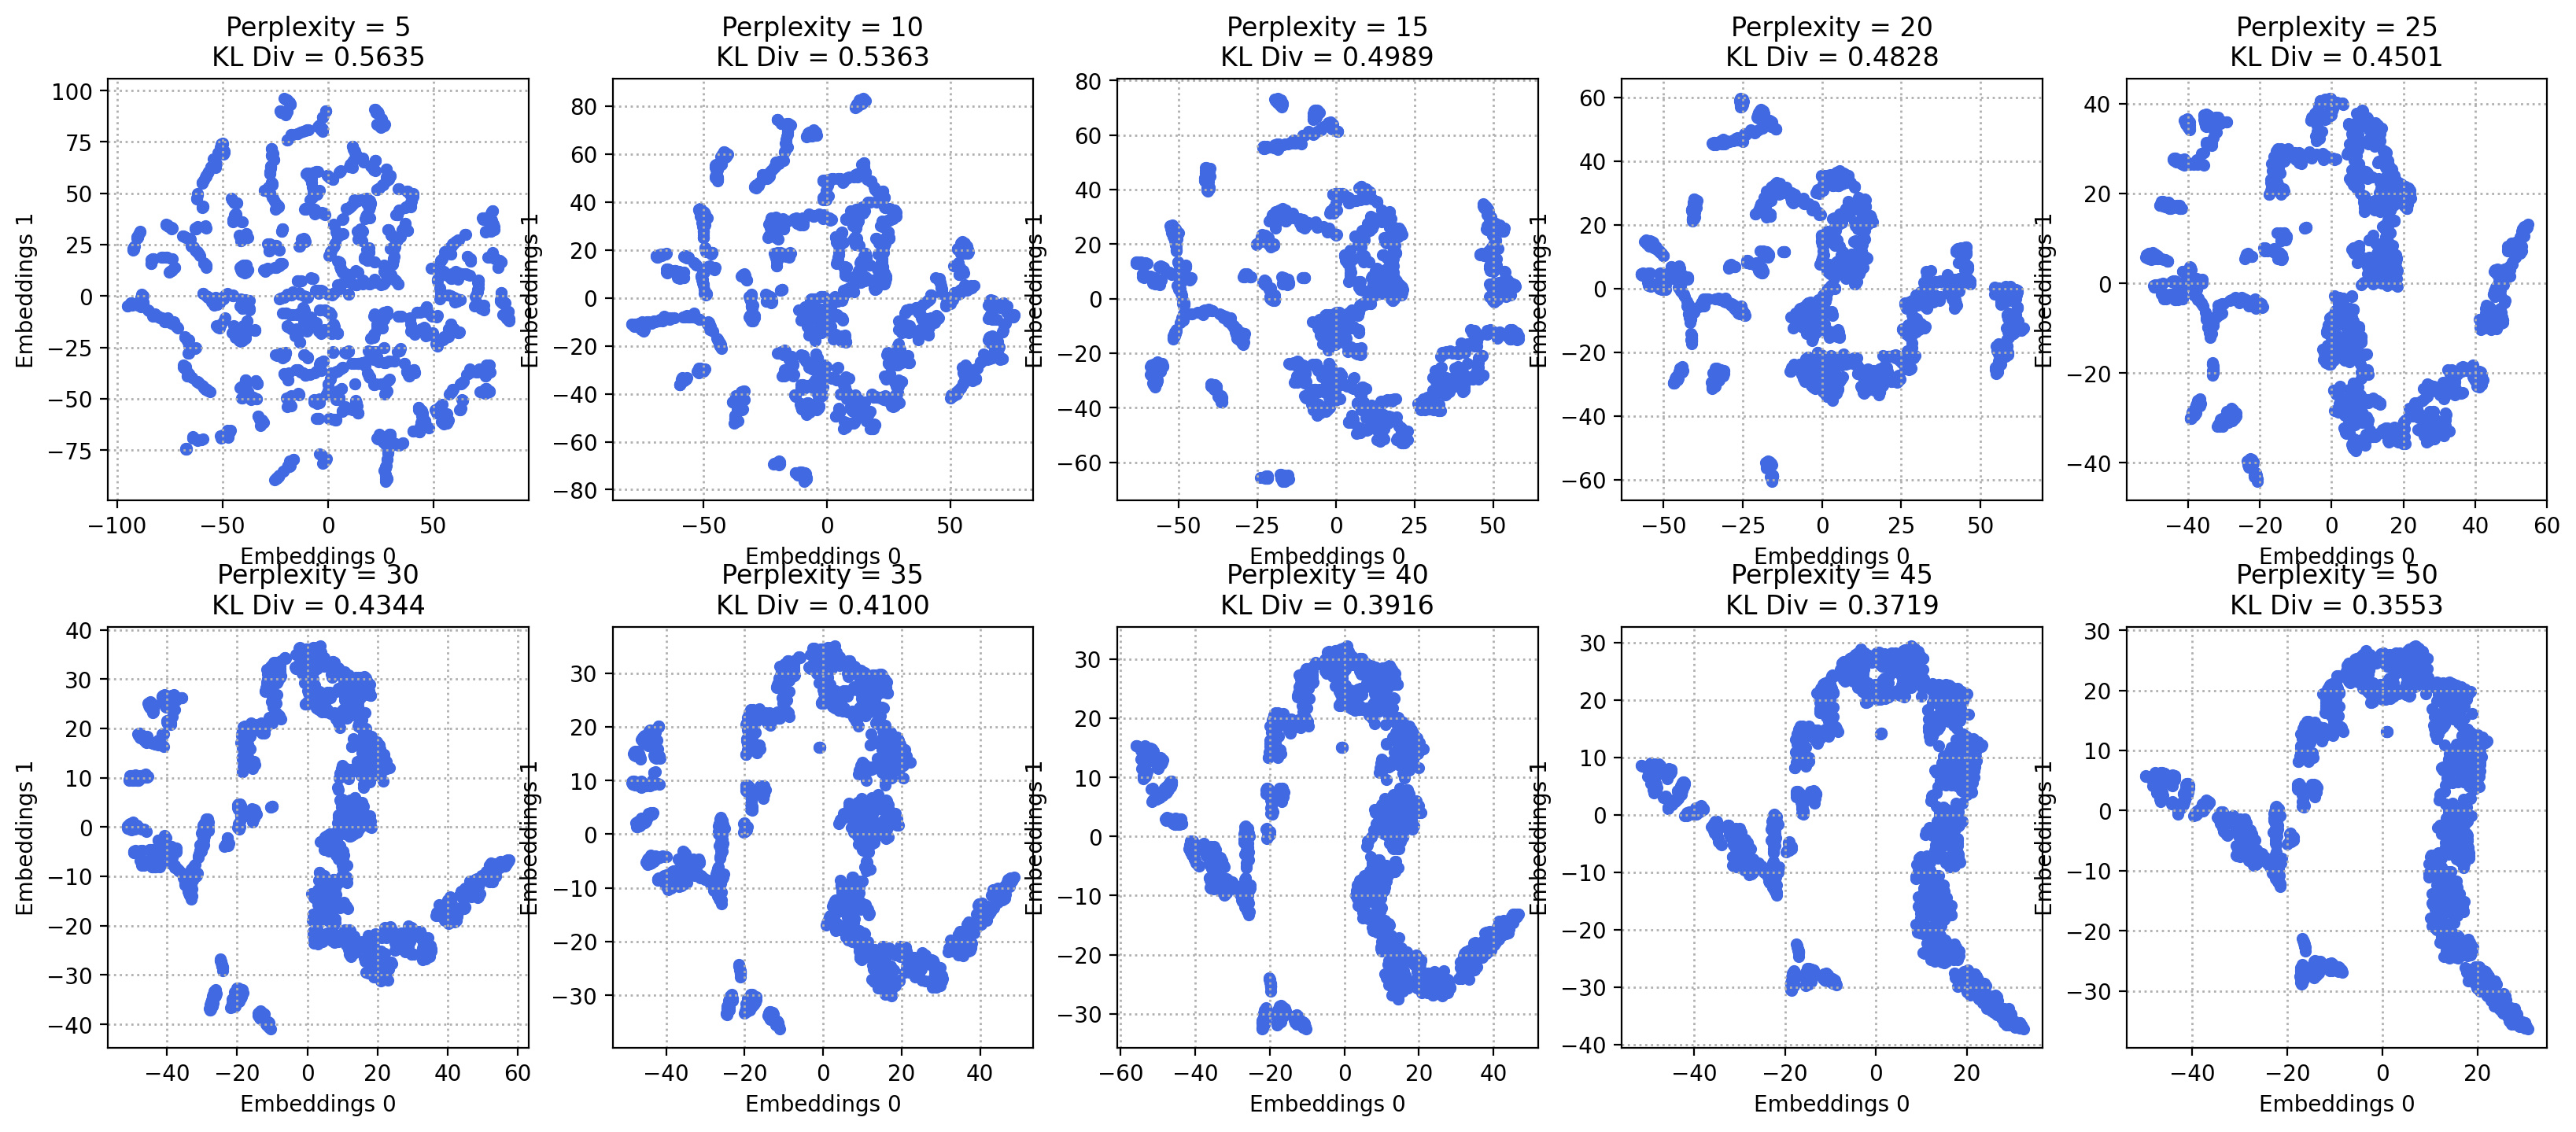

Minimum KL Divergence: 0.3553 at Perplexity: 50


In [ ]:
# This is code taken from Dr. Lam from "Week 4 Visualize High Dimensional Data.py"
# and edited to display KL values

# Visualize the possible number of clusters by the t-SNE method
# Initialize a list to store KL values
kl_values = []
perplexities = list(range(5, 51, 5))

fig, axs = plt.subplots(2, 5, figsize = (20,8), dpi = 200)
fig.subplots_adjust(hspace = 0.3)
i = 0
j = 0
aseed = 710136202

for k in perplexities:
    obj_tsne = TSNE(n_components = 2, perplexity = k, random_state = aseed)
    
    # fit() computes the embeddings and the KL divergence
    tsne_0 = obj_tsne.fit(traindata)
    
    # PULL THE KL VALUE HERE
    kl_values.append(tsne_0.kl_divergence_)
    
    embeddings = tsne_0.embedding_
    aseed += 31
    
    ax = axs[i,j]
    ax.set_title(f'Perplexity = {k}\nKL Div = {tsne_0.kl_divergence_:.4f}')
    ax.scatter(embeddings[:,0], embeddings[:,1], c = 'royalblue', s = 20, marker ='o')
    ax.set_xlabel('Embeddings 0')
    ax.set_ylabel('Embeddings 1')
    ax.grid(axis = 'both', linestyle = ':', linewidth = 1)
    
    j += 1
    if (j > 4):
        j = 0
        i += 1

plt.show()

# Identify the best perplexity
best_idx = np.argmin(kl_values)
print(f"Minimum KL Divergence: {kl_values[best_idx]:.4f} at Perplexity: {perplexities[best_idx]}")

(b)	(10 points) How many clusters will you identify based on the above scatterplots?

3 because we can see one small cluster on the bottom, one arched cluster in the middle-right, and a straight cluster on the left.

### Question 4 (20 points)

After choosing the perplexity value that results in the smallest Kullback–Leibler divergence, you'll find meaningful clusters within the t-SNE embeddings.

(a)	(10 points) Try the number of clusters between 2 and 15 inclusively, then plot the Elbow values, the Silhouette Scores, the Calinski and Harabasz Scores, and the Davies-Bouldin Scores versus the number of clusters. Your initial random seed is 710136264; add 31 after each trial.

In [86]:
metric_df = (suggest_n_clusters(traindata, k_choices=range(2,16)))
metric_df.head()

,N Clusters,Elbow Train,Silhouette Train,CH Train,DB Train
0,2,1.071024e+06,0.520891,1620.680710,0.815372
1,3,4.383597e+05,0.565814,3068.213943,0.535653
2,4,2.607977e+05,0.508617,3778.324687,0.564911
3,5,1.978413e+05,0.472243,3852.989801,0.626277
4,6,1.613253e+05,0.471047,3845.969672,0.656754


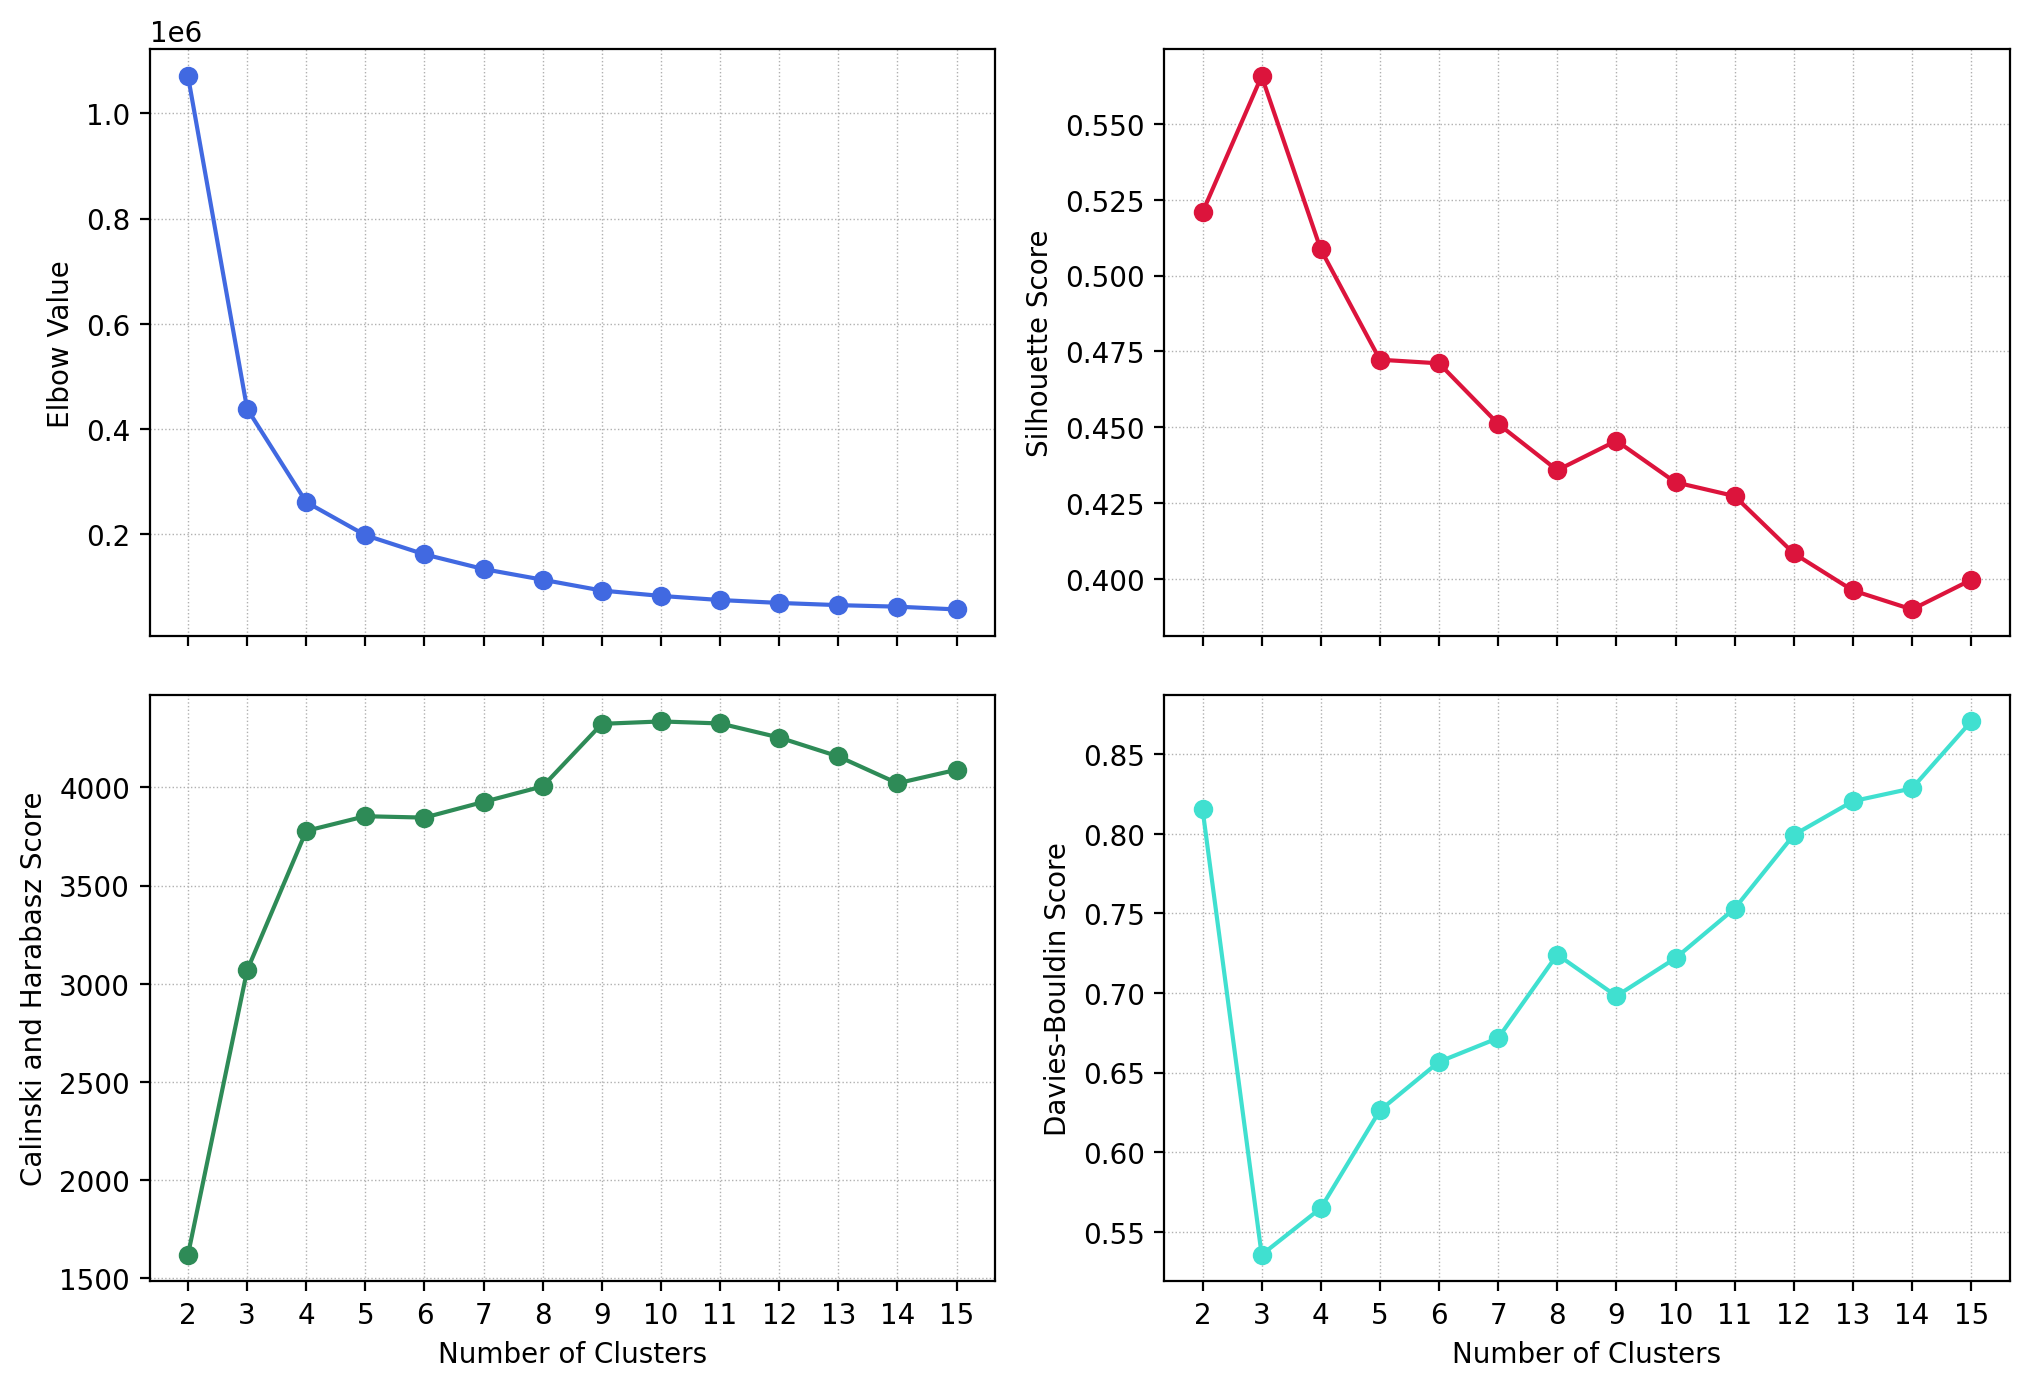

In [88]:
show_cluster_metric(metric_df)

(b)	(10 points) What will you suggest for the number of clusters based on the four metrics?

3